<a href="https://colab.research.google.com/github/by-anasantos/Diff-in-Diff-Case-Study/blob/main/pricing_experiment_econometric_evaluation_did_port.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Sumário Executivo

Este estudo utiliza a metodologia Difference-in-Differences (Diff-in-Diff) para estimar o efeito causal de um desconto de 15% na primeira compra, sob as premissas do modelo.

**Principais resultados:**

*Purchases:* aumento médio de **+110 unidades por empresa**, com evidência estatística robusta.

*Pack Views:* crescimento significativo de demanda, com aumento médio de **+636 visualizações por empresa**.

*Conversion:* efeito positivo estimado, porém com alta incerteza e sem poder estatístico suficiente para conclusões robustas.

**Poder Estatístico**

O experimento apresentou poder estatístico adequado para detectar efeitos em métricas de volume (*purchases* e *views*), mas insuficiente para identificar pequenas variações na taxa de conversão.

**Interpretação**

Os resultados indicam que o desconto atua principalmente como alavanca de **geração de demanda (topo do funil)**, aumentando a exposição e o volume de compras.

No entanto, não há evidência robusta de melhoria na eficiência de conversão, e a interpretação causal depende das premissas do modelo, em especial a hipótese de tendências paralelas.

**Conclusão**

O desconto de 15% apresenta impacto positivo e robusto em métricas de volume, especialmente *pack views* e *purchases*.  

No entanto, os efeitos sobre conversão permanecem inconclusivos, e os resultados devem ser interpretados com cautela, considerando limitações de poder estatístico e dependência das premissas do modelo.

#0. Contexto do Case

##0.1 Objetivo da análise

Avaliar o impacto causal de um desconto de 15% no desempenho de class packs.

##0.2 Estrutura do Experimento



*  Grupo Teste vs Grupo Controle
*   Período Pré vs Pós
*   Métricas de funil: Views → Purchases → Conversion

#1.Carregamento e entendimento inicial dos dados

##1.1 Importação das bibliotecas

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import norm
from statsmodels.stats.proportion import proportions_ztest


##1.2 Carregamento do dataset

### Data Source

The dataset used in this analysis is not included in the repository.

In [67]:
df_raw = pd.read_excel("excel_file", sheet_name='Raw Data')

##1.3 Dicionário de dados

In [68]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 6 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Company ID                  400 non-null    int64 
 1   Period                      400 non-null    object
 2   Test Cohort                 400 non-null    object
 3   Pack Views                  400 non-null    int64 
 4   Purchases                   400 non-null    int64 
 5   Market_Standard_Pack_Price  400 non-null    int64 
dtypes: int64(4), object(2)
memory usage: 18.9+ KB


Dicionário


*Company ID*: Unique ID corresponding to a studio/company\
*Period*: If data corresponds to pre-test or post-test\
*Test Cohort*: Control - no discount; Test - 15% discount\
*Pack Views*: Count of Views to the pack purchase page\
*Purchases*: Count of Purchases made during period\
*Market Standard Pack Price* : Cost of a pack, pre-discount



#2.Checagens de qualidade e integridade do experimento

##2.1 Verificação dos nulos

In [69]:
df_raw.isnull().count()

,0
Company ID,400
Period,400
Test Cohort,400
Pack Views,400
Purchases,400
Market_Standard_Pack_Price,400


Sem valores nulos

##2.2 Verificação de registros duplicados

In [70]:
df_duplicates = df_raw[df_raw.duplicated(keep=False)]

In [71]:
df_duplicates

,Company ID,Period,Test Cohort,Pack Views,Purchases,Market_Standard_Pack_Price


Sem valores duplicados

##2.3 Cada empresa possui observação em Pre e Post?

In [72]:
df_raw.groupby("Company ID")["Period"].nunique().value_counts()

,count
Period,
2,200


Todas as empresas possuem Pre e Post

##2.4 Verificação de vazamento de tratamento

Uma mesma empresa não deve ter mudado de grupo de preço entre o pre e post pois comprometeria a identificação causal

In [73]:
df_raw.groupby("Company ID")["Test Cohort"].nunique().value_counts()

,count
Test Cohort,
1,199
2,1


In [74]:
df_raw.groupby("Company ID")["Test Cohort"].nunique().sort_values(ascending=False).head()

,Test Cohort
Company ID,
101,2
1,1
3,1
2,1
5,1


##2.5 Exclusão de observações inválidas

A empresa company id 101 não será considerada na análise.

In [75]:
INVALID_COMPANY_IDS = [101]

In [76]:
df_clean = df_raw[~df_raw["Company ID"].isin(INVALID_COMPANY_IDS)].copy()

1 empresa precisou ser excluída da análise

##2.6 Preço do pack é fixo por empresa?

In [77]:
df_clean.groupby("Company ID")["Market_Standard_Pack_Price"].nunique().value_counts()

,count
Market_Standard_Pack_Price,
1,199


Os preços por empresa não mudaram

##2.7 Sanity check do funil (Views ≥ Purchases)

In [78]:
(df_clean["Pack Views"] > df_clean["Purchases"]).mean()

np.float64(1.0)

A quantidade de views foi maior do que a quantidade de purchases

In [79]:
df_clean = df_clean.rename(columns={
    "Company ID": "company_id",
    "Period": "period",
    "Test Cohort": "test_cohort",
    "Pack Views": "pack_views",
    "Purchases": "purchases",
    "Market_Standard_Pack_Price": "market_standard_pack_price"
})

df_clean["period"] = df_clean["period"].str.lower()
df_clean["test_cohort"] = df_clean["test_cohort"].str.lower()



#3.Construção de métricas derivadas

##3.1 Criação da taxa de conversão

In [80]:
df_clean["conversion"] = df_clean["purchases"] / df_clean["pack_views"]


##3.2 Criação de métricas derivadas

In [81]:
df_clean["post"] = (df_clean["period"] == "post").astype(int)
df_clean["treatment"] = (df_clean["test_cohort"] == "test").astype(int)

In [82]:
FUNNEL_METRICS = ["pack_views", "purchases", "conversion"]

#4.Framework Causal

O DiD responde:
“Quanto essas empresas teriam crescido mesmo sem desconto?”

Subtraindo a tendência do grupo controle, isolamos:\
estimativa do crescimento incremental atribuível ao desconto, sob as premissas do modelo.

*  Unidade: empresa (company_id)  
*  Tratamento: desconto de 15% (treatment=1)
*   Períodos: pré e pós (post=1 no pós)  
*   Outcomes: pack_views, purchases, conversion  


Assumimos:

- SUTVA (sem interferência entre empresas)
- Tendências paralelas (parallel trends): na ausência do tratamento, os grupos tratado e controle teriam evoluído de forma semelhante ao longo do tempo
- Sem antecipação relevante no período pré

Nota importante:
Embora o experimento tenha sido desenhado com randomização, a premissa de tendências paralelas não é automaticamente garantida e não pôde ser formalmente validada nesta análise devido à limitação de períodos pré-tratamento.

Portanto, a validade da interpretação causal dos resultados depende dessa hipótese.

Estimamos o efeito causal médio para tratadas (ATT) usando Diff-in-Diff:

τ_DiD = (E[Y|T=1,post=1] - E[Y|T=1,post=0]) - (E[Y|T=0,post=1] - E[Y|T=0,post=0])


<table style="border-collapse:collapse;width:100%;font-family:Arial, sans-serif;font-size:14px;">
  <thead>
    <tr>
      <th style="border:1px solid #ddd;padding:10px;text-align:left;background:#f5f5f5;">Termo</th>
      <th style="border:1px solid #ddd;padding:10px;text-align:left;background:#f5f5f5;">Significado técnico</th>
      <th style="border:1px solid #ddd;padding:10px;text-align:left;background:#f5f5f5;">Explicação executiva (business)</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="border:1px solid #ddd;padding:10px;">
        E[Y | T=1, post=1]
      </td>
      <td style="border:1px solid #ddd;padding:10px;">
        Média do outcome nas empresas tratadas após o desconto
      </td>
      <td style="border:1px solid #ddd;padding:10px;">
        Quanto as empresas com desconto performaram depois da intervenção
      </td>
    </tr>
    <tr>
      <td style="border:1px solid #ddd;padding:10px;">
        E[Y | T=1, post=0]
      </td>
      <td style="border:1px solid #ddd;padding:10px;">
        Média do outcome nas empresas tratadas antes do desconto
      </td>
      <td style="border:1px solid #ddd;padding:10px;">
        Performance inicial das empresas que depois receberam desconto
      </td>
    </tr>
    <tr>
      <td style="border:1px solid #ddd;padding:10px;">
        E[Y | T=0, post=1]
      </td>
      <td style="border:1px solid #ddd;padding:10px;">
        Média do outcome nas empresas controle após o período
      </td>
      <td style="border:1px solid #ddd;padding:10px;">
        Como o mercado evoluiu no mesmo período sem desconto
      </td>
    </tr>
    <tr>
      <td style="border:1px solid #ddd;padding:10px;">
        E[Y | T=0, post=0]
      </td>
      <td style="border:1px solid #ddd;padding:10px;">
        Média do outcome nas empresas controle antes do período
      </td>
      <td style="border:1px solid #ddd;padding:10px;">
        Baseline das empresas que nunca receberam desconto
      </td>
    </tr>
    <tr>
      <td style="border:1px solid #ddd;padding:10px;"><b>DiD</b></td>
      <td style="border:1px solid #ddd;padding:10px;">
        (Variação tratadas − variação controle)
      </td>
      <td style="border:1px solid #ddd;padding:10px;">
        Estimativa do efeito incremental do desconto acima da tendência contrafactual do grupo controle
      </td>
    </tr>
    <tr>
      <td style="border:1px solid #ddd;padding:10px;"><b>Resultado (τ<sub>DiD</sub>)</b></td>
      <td style="border:1px solid #ddd;padding:10px;">
        Estimativa do ATT
      </td>
      <td style="border:1px solid #ddd;padding:10px;">
        Impacto causal médio do desconto nas empresas tratadas
      </td>
    </tr>
  </tbody>
</table>



### Interpretação Causal (sob premissas)

O estimador Diff-in-Diff identifica o efeito causal médio (ATT) sob a premissa de tendências paralelas.

É importante destacar que significância estatística não garante validade causal caso essa premissa não seja satisfeita.

#5.EDA

In [83]:
tbl_means = (
    df_clean.groupby(["period","test_cohort"])[FUNNEL_METRICS]
      .mean()
      .round(4)
)
tbl_means


pack_views  purchases  conversion
period test_cohort                                   
post   control       4923.0500   426.5200      0.1440
       test          6294.2222   610.2727      0.1342
pre    control       4834.5100   429.6200      0.1468
       test          5570.0909   503.6263      0.1254

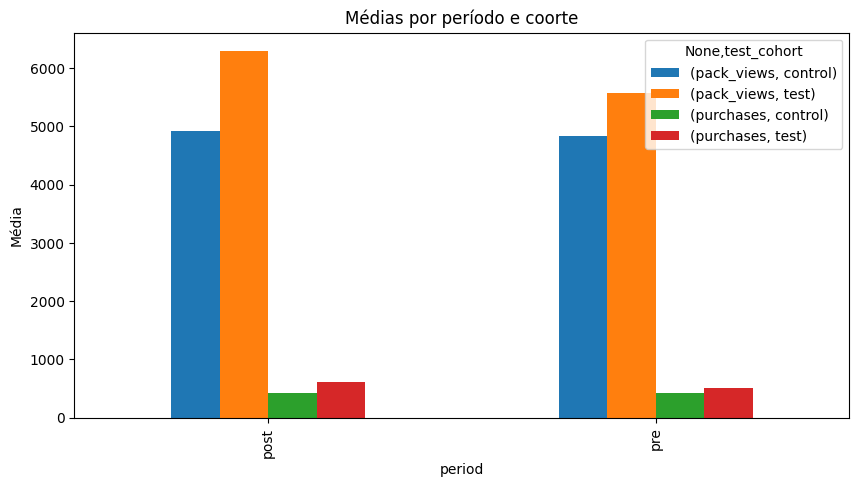

In [84]:
(
    df_clean.groupby(["period","test_cohort"])[["pack_views","purchases"]]
      .mean()
      .unstack("test_cohort")
).plot(kind="bar", figsize=(10,5))
plt.title("Médias por período e coorte")
plt.ylabel("Média")
plt.show()


#6.Validação de comparabilidade no pré-período (Baseline)

Objetivo: verificar se Teste e Controle eram comparáveis antes do desconto.

##6.1 Purchases e Views (diferença de médias no pré)

In [85]:
df_pre = df_clean[df_clean["period"]=="pre"].copy()

m_balance_purchases = smf.ols("purchases ~ treatment", data=df_pre).fit(
    cov_type="HC1"
)
print(m_balance_purchases.summary().tables[1])


                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    429.6200     30.166     14.242      0.000     370.496     488.744
treatment     74.0063     42.348      1.748      0.081      -8.995     157.007


*Intercept* = 429.62 -> Empresas controle tinham, em média, 429 compras antes do desconto.

*Coeficiente treatment* = 74.01 ->Empresas tratadas tinham, em média, 74 compras a mais que o controle antes do desconto.

*p-valor*= 0.081 ->
Não é significativo a 5%
Mas é marginal (quase significativo a 10%)

*Intervalo de confiança: [-8.995, 157.007]*
A diferença verdadeira pode ser negativa\
Pode ser zero\
Pode ser até +157\
Como inclui zero → não posso afirmar diferença estatística com confiança de 95%.


Antes do desconto, as empresas tratadas tinham, em média, 74 compras a mais do que as do grupo controle.

Mas essa diferença não é estatisticamente significativa ao nível de 5%, ou seja, não podemos afirmar com segurança que os grupos eram diferentes no início.

Em resumo:
não há evidência forte de desequilíbrio no pré, embora exista um leve sinal de que as tratadas possam ser um pouco maiores.

In [86]:
m_balance_views = smf.ols("pack_views ~ treatment", data=df_pre).fit(
    cov_type="HC1"
)
print(m_balance_views.summary().tables[1])

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   4834.5100    295.791     16.344      0.000    4254.770    5414.250
treatment    735.5809    390.928      1.882      0.060     -30.624    1501.785


Intercept = 4834.51 → Empresas controle tinham, em média, 4.834 visualizações antes do desconto.

Coeficiente treatment = 735.59 → Empresas tratadas tinham, em média, 736 visualizações a mais que o controle antes do desconto.

p-valor = 0.060 → Não é significativo a 5%, mas é marginal (quase significativo a 10%).

Intervalo de confiança: [-30.624, 1501.785]
A diferença verdadeira pode ser negativa.
Pode ser zero.
Pode ser até +1.502 visualizações.
Como inclui zero → não posso afirmar diferença estatística com confiança de 95%.

### Interpretação dos resultados


Antes do desconto, as empresas tratadas tinham, em média, 736 visualizações a mais do que as do grupo controle.  
No entanto, essa diferença não apresenta evidência estatística suficiente para afirmar diferença ao nível de 5%.

O resultado é marginal (p ≈ 0.06), sugerindo possível desequilíbrio inicial.

Isso pode indicar que as empresas tratadas já apresentavam maior volume antes do experimento,
o que reforça a importância da premissa de tendências paralelas na interpretação do Diff-in-Diff.

##6.2 Conversão no pré (teste de proporções agregado)

In [87]:
pre_test = df_pre[df_pre["treatment"]==1]
pre_ctrl = df_pre[df_pre["treatment"]==0]

success_test = pre_test["purchases"].sum()
n_test = pre_test["pack_views"].sum()

success_ctrl = pre_ctrl["purchases"].sum()
n_ctrl = pre_ctrl["pack_views"].sum()

stat, p_val = proportions_ztest([success_test, success_ctrl], [n_test, n_ctrl])

print(f"Z-test proporções (conversion, pré): stat={stat:.4f}, p-value={p_val:.4f}")


Z-test proporções (conversion, pré): stat=2.7548, p-value=0.0059


O teste de proporções indica diferença estatisticamente significativa na taxa de conversão entre os grupos no período pré (p < 0.01).

Isso sugere possível desequilíbrio inicial, o que pode afetar a interpretação causal dos resultados e reforça a importância da premissa de tendências paralelas no Diff-in-Diff.

#7. Estimação Causal (v1) — DiD por Regressão + Cluster SE

O coeficiente da interação entre tratamento e período pós (treatment × post)
representa a estimativa do efeito causal médio (ATT) do desconto.

##7.1 Purchases (nível)

Comparação inicial entre grupos no período pós.

In [88]:
m_did_purchases = smf.ols(
    "purchases ~ treatment*post",
    data=df_clean
).fit(cov_type="cluster", cov_kwds={"groups": df_clean["company_id"]})

print(m_did_purchases.summary().tables[1])



                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept        429.6200     30.204     14.224      0.000     370.421     488.819
treatment         74.0063     42.402      1.745      0.081      -9.099     157.112
post              -3.1000      6.228     -0.498      0.619     -15.307       9.107
treatment:post   109.7465     10.242     10.715      0.000      89.672     129.821


Neste caso específico, os resultados são consistentes entre as abordagens.
No entanto, a inclusão de efeitos fixos pode alterar significativamente as estimativas em outros contextos.

comparando a mesma empresa antes e depois da intervenção

In [89]:
m_did_purchases_3 = smf.ols(
    "purchases ~ treatment:post + C(company_id) + C(period)",
    data=df_clean
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_clean["company_id"]}
)
coef = m_did_purchases_3.params["treatment:post"]
se = m_did_purchases_3.bse["treatment:post"]
pval = m_did_purchases_3.pvalues["treatment:post"]
ci_low, ci_high = m_did_purchases_3.conf_int().loc["treatment:post"]

print(f"Coeficiente (ATT): {coef:.2f}")
print(f"Erro padrão: {se:.2f}")
print(f"p-valor: {pval:.4f}")
print(f"IC 95%: [{ci_low:.2f}, {ci_high:.2f}]")



Coeficiente (ATT): 109.75
Erro padrão: 14.49
p-valor: 0.0000
IC 95%: [81.36, 138.14]


O modelo inclui a interação treatment:post, além de efeitos fixos de empresa (C(company_id)) e de período (C(period)).

Os termos treatment e post não aparecem explicitamente no modelo, pois são absorvidos pelos efeitos fixos de empresa e de período, respectivamente.

Interpretação:
O coeficiente da interação treatment:post representa a estimativa do efeito causal médio (ATT) no modelo de Two-Way Fixed Effects DiD.

Essa especificação compara a evolução da mesma empresa ao longo do tempo, controlando tanto por características fixas da empresa quanto por choques agregados comuns a todos no período.

In [90]:
att = m_did_purchases_3.params["treatment:post"]

print(f"O desconto está associado a um aumento médio de aproximadamente 109.7 compras por empresa no período pós, sob as premissas do modelo..")


O desconto está associado a um aumento médio de aproximadamente 109.7 compras por empresa no período pós, sob as premissas do modelo..


Neste caso específico, os resultados são consistentes entre as especificações.
No entanto, em geral, a inclusão de efeitos fixos pode alterar significativamente as estimativas.

### Análise de poder a partir da regressão — Purchases

In [91]:
import numpy as np
from scipy.stats import norm

# pegar coeficiente e SE
beta = m_did_purchases_3.params["treatment:post"]
se = m_did_purchases_3.bse["treatment:post"]

# t-stat
t_stat = beta / se

# nível de significância
alpha = 0.05
z_alpha = norm.ppf(1 - alpha/2)

# power aproximado
power = 1 - norm.cdf(z_alpha - abs(t_stat))

print(f"t-stat: {t_stat:.2f}")
print(f"Power aproximado: {power:.3f}")


t-stat: 7.58
Power aproximado: 1.000


O poder estatístico aproximado de 1.00 sugere que o experimento está bem dimensionado para detectar efeitos na métrica de purchases.

Portanto, a evidência para impacto em volume de compras é estatisticamente robusta.

##7.2 Pack Views (nível)

In [92]:
m_did_views = smf.ols(
    "pack_views ~ treatment:post + C(company_id) + C(period)",
    data=df_clean
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_clean["company_id"]}
)


coef_views = m_did_views.params["treatment:post"]
se_views = m_did_views.bse["treatment:post"]
pval_views = m_did_views.pvalues["treatment:post"]
ci_low_views, ci_high_views = m_did_views.conf_int().loc["treatment:post"]

print(f"Coeficiente (ATT): {coef_views:.2f}")
print(f"Erro padrão: {se_views:.2f}")
print(f"p-valor: {pval_views:.4f}")
print(f"IC 95%: [{ci_low_views:.2f}, {ci_high_views:.2f}]")



Coeficiente (ATT): 635.59
Erro padrão: 112.03
p-valor: 0.0000
IC 95%: [416.01, 855.17]


O coeficiente da interação (treatment × post) indica um aumento médio de aproximadamente 636 visualizações por empresa no período pós.

O resultado é estatisticamente significativo (p < 0.01) e o intervalo de confiança não inclui zero, sugerindo um efeito robusto do desconto sobre a demanda no topo do funil, sob as premissas do modelo.

#7.3 Conversion (LPM — simples e interpretável)

In [93]:
m_did_conversion = smf.ols(
    "conversion ~ treatment:post + C(company_id) + C(period)",
    data=df_clean
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_clean["company_id"]}
)

coef_conversion = m_did_conversion .params["treatment:post"]
se_conversion = m_did_conversion .bse["treatment:post"]
pval_conversion = m_did_conversion .pvalues["treatment:post"]
ci_low_conversion, ci_high_conversion = m_did_conversion .conf_int().loc["treatment:post"]

print(f"Coeficiente (ATT): {coef_conversion:.2f}")
print(f"Erro padrão: {se_conversion :.2f}")
print(f"p-valor: {pval_conversion:.4f}")
print(f"IC 95%: [{ci_low_conversion:.2f}, {ci_high_conversion:.2f}]")

Coeficiente (ATT): 0.01
Erro padrão: 0.01
p-valor: 0.0254
IC 95%: [0.00, 0.02]


In [94]:
import numpy as np
from scipy.stats import norm

# pegar coeficiente e SE (conversion)
beta = m_did_conversion.params["treatment:post"]
se = m_did_conversion.bse["treatment:post"]

# z-stat
z_stat = beta / se

# nível de significância
alpha = 0.05
z_alpha = norm.ppf(1 - alpha/2)

# power aproximado (two-tailed)
power = (
    1 - norm.cdf(z_alpha - abs(z_stat)) +
    norm.cdf(-z_alpha - abs(z_stat))
)

print(f"z-stat: {z_stat:.2f}")
print(f"Power aproximado: {power:.3f}")

z-stat: 2.24
Power aproximado: 0.608


### Interpretação

Embora o modelo indique significância estatística, a análise de poder revela capacidade de detecção moderada (~60%), abaixo do nível usualmente desejado (80%).

Isso sugere que a estimativa pode ser sensível a variações amostrais e deve ser interpretada com cautela.

Diferenças entre métodos de estimação (regressão vs abordagem agregada) também podem contribuir para essa instabilidade.

#7.4 Extrair efeitos (coeficiente da interação)

In [95]:
did_purchases  = m_did_purchases.params["treatment:post"]
did_views      = m_did_views.params["treatment:post"]
did_conversion = m_did_conversion.params["treatment:post"]

se_purchases  = m_did_purchases.bse["treatment:post"]
se_views      = m_did_views.bse["treatment:post"]
se_conversion = m_did_conversion.bse["treatment:post"]

tbl_did = pd.DataFrame({
    "effect": [did_views, did_purchases, did_conversion],
    "se_cluster": [se_views, se_purchases, se_conversion],
}, index=["pack_views", "purchases", "conversion"])

tbl_did["ci_low"]  = tbl_did["effect"] - 1.96 * tbl_did["se_cluster"]
tbl_did["ci_high"] = tbl_did["effect"] + 1.96 * tbl_did["se_cluster"]

tbl_did.round(4)



,effect,se_cluster,ci_low,ci_high
pack_views,635.5913,112.0336,416.0055,855.1772
purchases,109.7465,10.2425,89.6712,129.8217
conversion,0.0116,0.0052,0.0014,0.0218


## Conclusão

- O desconto de 15% está associado a aumento robusto em pack views e purchases, indicando forte impacto na geração de demanda.
- Os resultados são estatisticamente significativos e suportados por alto poder estatístico nessas métricas.
- Para conversion, não há evidência conclusiva: o efeito é pequeno, com incerteza relevante e poder estatístico moderado.
- O desconto atua principalmente como alavanca de aquisição (topo do funil), com impacto limitado na eficiência de conversão.
- A interpretação causal depende das premissas do modelo, especialmente tendências paralelas, que não foram formalmente validadas.

#8. Validação do Diff-in-Diff por médias (tabela 2×2)

Como verificação adicional, reproduzimos a estimativa de Diff-in-Diff utilizando a abordagem clássica de médias agregadas (tabela 2×2).

Essa abordagem permite uma interpretação mais intuitiva do efeito e valida a consistência com os resultados obtidos via regressão.

##8.1.Pack Views

###8.1.1 Tabela 2×2

In [96]:
tbl_pack_views = (
    df_clean
        .groupby(["test_cohort", "period"])["pack_views"]
        .mean()
        .unstack("period")
)

###8.1.2 Cálculo do Diff-in-Diff

In [97]:
tbl_pack_views["delta"] = (
    tbl_pack_views["post"] -
    tbl_pack_views["pre"]
)
did_pack_views = (
    tbl_pack_views.loc["test", "delta"] -
    tbl_pack_views.loc["control", "delta"]
)

tbl_pack_views.loc["diff_in_diff", "delta"] = did_pack_views

tbl_pack_views


period,post,pre,delta
test_cohort,,,
control,4923.050000,4834.510000,88.540000
test,6294.222222,5570.090909,724.131313
diff_in_diff,NaN,NaN,635.591313


O efeito estimado indica aumento expressivo de tráfego no grupo tratado em relação ao controle.

##8.2.Purchases

###8.2.1 Tabela 2×2

In [98]:
tbl_purchases = (
    df_clean
        .groupby(["test_cohort", "period"])["purchases"]
        .mean()
        .unstack("period")
)
tbl_purchases["delta"] = (
    tbl_purchases["post"] -
    tbl_purchases["pre"]
)

###8.2.2 Cálculo do Diff-in-Diff

In [99]:
did_purchases = (
    tbl_purchases.loc["test", "delta"] -
    tbl_purchases.loc["control", "delta"]
)

tbl_purchases.loc["diff_in_diff", "delta"] = did_purchases

tbl_purchases

period,post,pre,delta
test_cohort,,,
control,426.520000,429.620000,-3.100000
test,610.272727,503.626263,106.646465
diff_in_diff,NaN,NaN,109.746465


Observa-se crescimento consistente em compras no grupo tratado, acima da tendência do controle.

##8.3.Conversion

###8.3.1 Tabela 2×2

In [100]:
tbl_conversion = (
    df_clean
        .groupby(["test_cohort", "period"])["conversion"]
        .mean()
        .unstack("period")
)
tbl_conversion["delta"] = (
    tbl_conversion["post"] -
    tbl_conversion["pre"]
)



###8.3.2 Cálculo do Diff-in-Diff

In [101]:
did_conversion = (
    tbl_conversion.loc["test", "delta"] -
    tbl_conversion.loc["control", "delta"]
)

tbl_conversion.loc["diff_in_diff", "delta"] = did_conversion

tbl_conversion



period,post,pre,delta
test_cohort,,,
control,0.144013,0.146836,-0.002823
test,0.134166,0.125386,0.008779
diff_in_diff,NaN,NaN,0.011602


O efeito em conversão é positivo, porém de menor magnitude.

Os resultados obtidos via médias são consistentes com a estimação por regressão, reforçando a robustez da evidência causal.

#9.Resultados principais do Diff-in-Diff

##9.1 Tabela resumo dos efeitos

In [102]:
tbl_did_summary = pd.Series(
    {
        "pack_views": did_pack_views,
        "purchases": did_purchases,
        "conversion": did_conversion,
    },
    name="diff_in_diff"
).to_frame()

tbl_did_summary.round(4)

,diff_in_diff
pack_views,635.5913
purchases,109.7465
conversion,0.0116


A tabela resume os efeitos estimados do desconto (Diff-in-Diff) em cada métrica do funil.

Observa-se impacto positivo relevante em métricas de volume, com maior magnitude em pack views e efeito consistente em purchases.

Para conversion, o efeito é positivo, porém substancialmente menor em magnitude.

#10.Análise de Poder

Objetivo - Avaliar se o experimento tinha poder estatístico suficiente para detectar um aumento mínimo relevante na taxa de conversão.\
Em geral, considera-se adequado poder ≥ 80%.

In [103]:
ALPHA = 0.05
TARGET_POWER = 0.80
z_alpha = norm.ppf(1 - ALPHA/2)
z_beta = norm.ppf(TARGET_POWER)

##10.1 Conversão

In [104]:

df_panel_conversion = (
    df_clean
        .pivot_table(
            index=["company_id", "test_cohort"],
            columns="period",
            values=["purchases", "pack_views"],
            aggfunc="sum"
        )
        .reset_index()
)
df_panel_conversion["conv_pre"] = (
    df_panel_conversion[("purchases", "pre")] /
    df_panel_conversion[("pack_views", "pre")]
)

df_panel_conversion["conv_post"] = (
    df_panel_conversion[("purchases", "post")] /
    df_panel_conversion[("pack_views", "post")]
)

df_panel_conversion["delta"] = (
    df_panel_conversion["conv_post"] -
    df_panel_conversion["conv_pre"]
)

s_delta_conversion_test = (
    df_panel_conversion[df_panel_conversion["test_cohort"]=="test"]["delta"]
)

s_delta_conversion_control = (
    df_panel_conversion[df_panel_conversion["test_cohort"]=="control"]["delta"]
)

n_test = len(s_delta_conversion_test)
n_control = len(s_delta_conversion_control)

effect_conversion = (
    s_delta_conversion_test.mean() -
    s_delta_conversion_control.mean()
)

p_pool = df_panel_conversion["conv_pre"].mean()

In [105]:
se_conversion = np.sqrt(
    p_pool*(1-p_pool)/n_test +
    p_pool*(1-p_pool)/n_control
)

ci_low_conversion = effect_conversion - z_alpha * se_conversion
ci_high_conversion = effect_conversion + z_alpha * se_conversion

z_effect_conversion = effect_conversion / se_conversion

power_conversion = 1 - norm.cdf(z_alpha - z_effect_conversion)

mde_conversion = (z_alpha + z_beta) * se_conversion


In [106]:
print(f"Efeito: {effect_conversion:.4f}")
print(f"IC95%: [{ci_low_conversion:.4f}, {ci_high_conversion:.4f}]")
print(f"Power: {power_conversion:.3f}")
print(f"MDE: {mde_conversion:.4f}")


Efeito: 0.0116
IC95%: [-0.0837, 0.1069]
Power: 0.043
MDE: 0.1362


### Interpretação da inconsistência

Os resultados de conversão variam entre abordagens devido a diferenças nos métodos de estimação (regressão com erros clusterizados vs agregação por médias), que implicam estruturas distintas de variância.

Embora a regressão indique significância estatística, a análise de poder mostra que o experimento possui baixa capacidade de detecção para efeitos dessa magnitude.

Isso sugere que o resultado não é robusto e pode não se reproduzir de forma consistente.

Em conjunto, a evidência para impacto em conversion é fraca, devendo ser interpretada com cautela.

Além disso, diferenças já presentes no período pré reforçam o risco de violação da hipótese de tendências paralelas para essa métrica.

##10.2 Purchases

In [107]:

df_panel_purchases = (
    df_clean
        .pivot_table(
            index=["company_id", "test_cohort"],
            columns="period",
            values="purchases",
            aggfunc="sum"
        )
        .reset_index()
)

df_panel_purchases = df_panel_purchases.dropna(subset=["pre", "post"]).copy()

df_panel_purchases["delta"] = (
    df_panel_purchases["post"] -
    df_panel_purchases["pre"]
)

s_delta_purchases_test = (
    df_panel_purchases[df_panel_purchases["test_cohort"]=="test"]["delta"]
)

s_delta_purchases_control = (
    df_panel_purchases[df_panel_purchases["test_cohort"]=="control"]["delta"]
)

n_test = len(s_delta_purchases_test)
n_control = len(s_delta_purchases_control)

effect_purchases = (
    s_delta_purchases_test.mean() -
    s_delta_purchases_control.mean()
)


In [108]:
se_purchases = np.sqrt(
    s_delta_purchases_test.var(ddof=1)/n_test +
    s_delta_purchases_control.var(ddof=1)/n_control
)

ci_low_purchases = effect_purchases - z_alpha * se_purchases
ci_high_purchases = effect_purchases + z_alpha * se_purchases

std_pooled = np.sqrt(
    ((n_test-1)*s_delta_purchases_test.var(ddof=1) +
     (n_control-1)*s_delta_purchases_control.var(ddof=1)) /
    (n_test + n_control - 2)
)

d = effect_purchases / std_pooled

delta_nc = d * np.sqrt((n_test*n_control)/(n_test+n_control))

power_purchases = 1 - norm.cdf(z_alpha - delta_nc)

denominator = np.sqrt((n_test*n_control)/(n_test+n_control))

d_mde = (z_alpha + z_beta) / denominator

mde_purchases = d_mde * std_pooled

In [109]:

print(f"Efeito: {effect_purchases:.2f}")
print(f"IC95%: [{ci_low_purchases:.2f}, {ci_high_purchases:.2f}]")
print(f"Power: {power_purchases:.3f}")
print(f"MDE: {mde_purchases:.2f}")


Efeito: 109.75
IC95%: [89.70, 129.80]
Power: 1.000
MDE: 28.62


##10.3 Click Views

In [110]:
df_panel_views = (
    df_clean
        .pivot_table(
            index=["company_id", "test_cohort"],
            columns="period",
            values="pack_views",
            aggfunc="sum"
        )
        .reset_index()
)

df_panel_views = df_panel_views.dropna(subset=["pre", "post"]).copy()

df_panel_views["delta"] = (
    df_panel_views["post"] -
    df_panel_views["pre"]
)

s_delta_views_test = (
    df_panel_views[df_panel_views["test_cohort"]=="test"]["delta"]
)

s_delta_views_control = (
    df_panel_views[df_panel_views["test_cohort"]=="control"]["delta"]
)

n_test = len(s_delta_views_test)
n_control = len(s_delta_views_control)

effect_views = (
    s_delta_views_test.mean() -
    s_delta_views_control.mean()
)


In [111]:
se_views = np.sqrt(
    s_delta_views_test.var(ddof=1)/n_test +
    s_delta_views_control.var(ddof=1)/n_control
)

ci_low_views = effect_views - z_alpha * se_views
ci_high_views = effect_views + z_alpha * se_views

std_pooled = np.sqrt(
    ((n_test-1)*s_delta_views_test.var(ddof=1) +
     (n_control-1)*s_delta_views_control.var(ddof=1)) /
    (n_test + n_control - 2)
)

d = effect_views / std_pooled

delta_nc = d * np.sqrt((n_test*n_control)/(n_test+n_control))

power_views = 1 - norm.cdf(z_alpha - delta_nc)

denominator = np.sqrt((n_test*n_control)/(n_test+n_control))

d_mde = (z_alpha + z_beta) / denominator

mde_views = d_mde * std_pooled

In [112]:
print(f"Efeito: {effect_views:.2f}")
print(f"IC95%: [{ci_low_views:.2f}, {ci_high_views:.2f}]")
print(f"Power: {power_views :.3f}")
print(f"MDE: {mde_views:.2f}")


Efeito: 635.59
IC95%: [480.52, 790.66]
Power: 1.000
MDE: 222.09


### Conclusão do poder estatístico

- O experimento apresenta alto poder estatístico para métricas de volume (views e purchases), indicando capacidade robusta de detecção de efeitos.
- Para conversion, o experimento está subdimensionado para detectar variações pequenas, apresentando baixo poder estatístico.
- Em conjunto, há evidência robusta de impacto em volume, mas resultados inconclusivos para eficiência do funil.

##Conclusão e Recomendação

O desconto de 25% pode gerar maior receita se o aumento nas vendas for pelo menos 13% maior do que o observado com 15%.

A projeção por faixa de preço mostra potencial ganho caso a demanda continue respondendo da mesma forma. No entanto, se a resposta diminuir, o retorno esperado cai de forma relevante.

Além disso, apenas 18% do volume observado com 15% foi realmente incremental. Isso indica que a maior parte das vendas já ocorreria sem desconto.

Portanto, recomenda-se testar 25% de forma segmentada antes de considerar uma implementação ampla.